<a href="https://www.arduino.cc/"><img src="https://raw.githubusercontent.com/sandeepmistry/aimldevfest-workshop-2019/master/images/Arduino_logo_R_highquality.png" width=200/></a>
# Tiny ML on Arduino
## Gesture recognition tutorial
 * Sandeep Mistry - Arduino
 * Don Coleman - Chariot Solutions


https://github.com/arduino/ArduinoTensorFlowLiteTutorials/

## Setup Python Environment

The next cell sets up the dependencies in required for the notebook, run it.

In [1]:
# Setup environment
!apt-get -qq install xxd
!pip install pandas numpy matplotlib
!pip install tensorflow==2.0.0-rc1

ERROR: Could not find a version that satisfies the requirement tensorflow==2.0.0-rc1 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow==2.0.0-rc1


# Upload Data

1. Open the panel on the left side of Colab by clicking on the __>__
1. Select the files tab
1. Drag `punch.csv` and `flex.csv` files from your computer to the tab to upload them into colab.

# Graph Data (optional)

We'll graph the input files on two separate graphs, acceleration and gyroscope, as each data set has different units and scale.

/tmp/ipykernel_364/3007413460.py:21: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "g." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['aX'], 'g.', label='x', linestyle='solid', marker=',')
/tmp/ipykernel_364/3007413460.py:22: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "b." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['aY'], 'b.', label='y', linestyle='solid', marker=',')
/tmp/ipykernel_364/3007413460.py:23: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "r." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['aZ'], 'r.', label='z', linestyle='solid', marker=',')


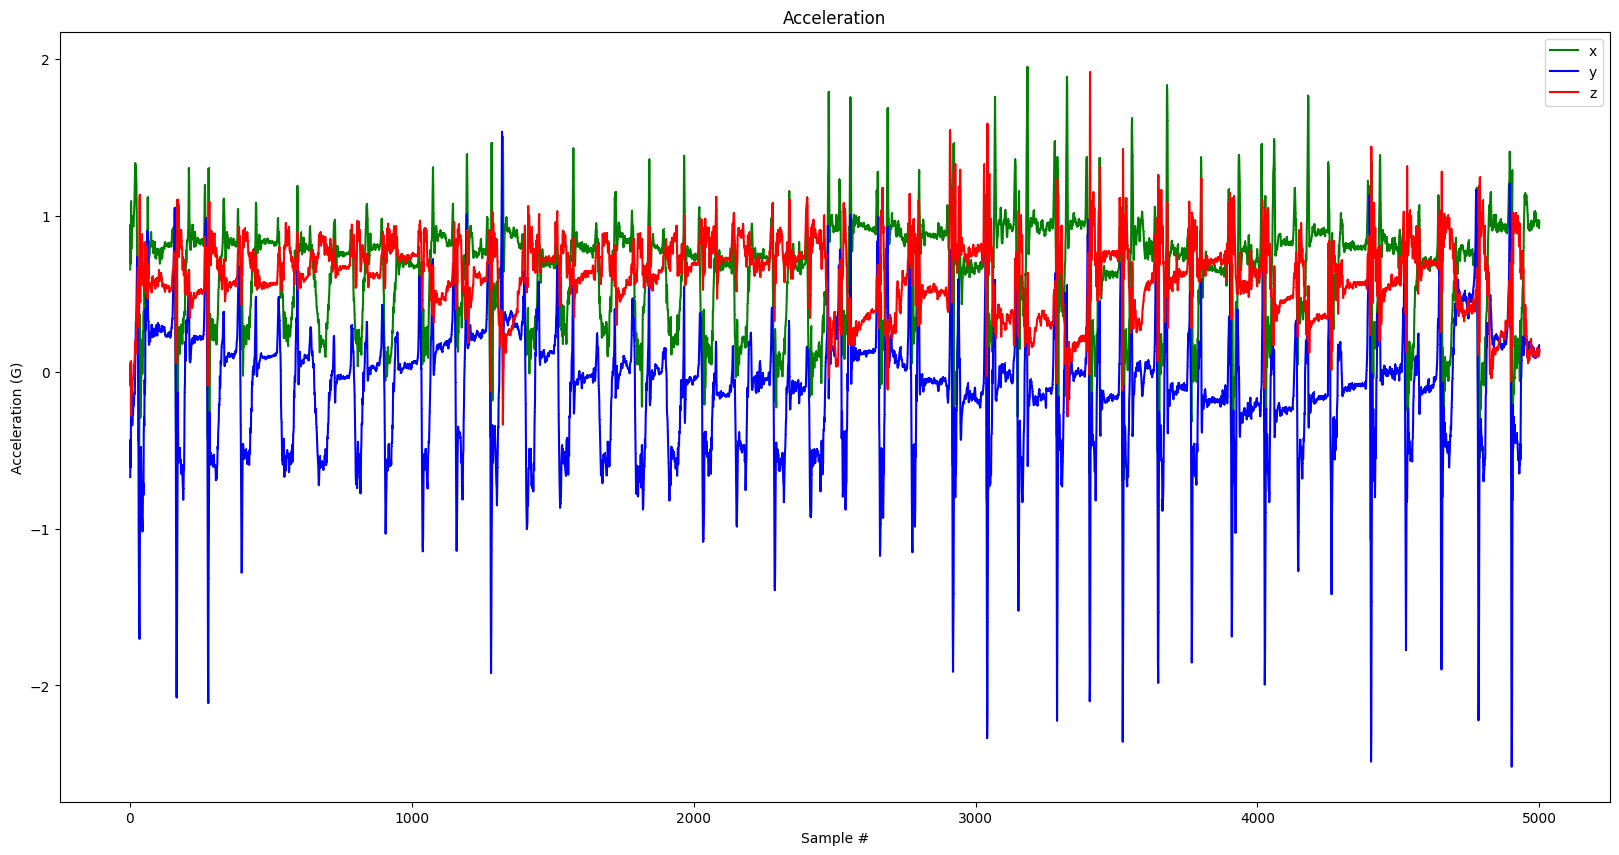

/tmp/ipykernel_364/3007413460.py:30: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "g." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['gX'], 'g.', label='x', linestyle='solid', marker=',')
/tmp/ipykernel_364/3007413460.py:31: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "b." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['gY'], 'b.', label='y', linestyle='solid', marker=',')
/tmp/ipykernel_364/3007413460.py:32: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "r." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['gZ'], 'r.', label='z', linestyle='solid', marker=',')


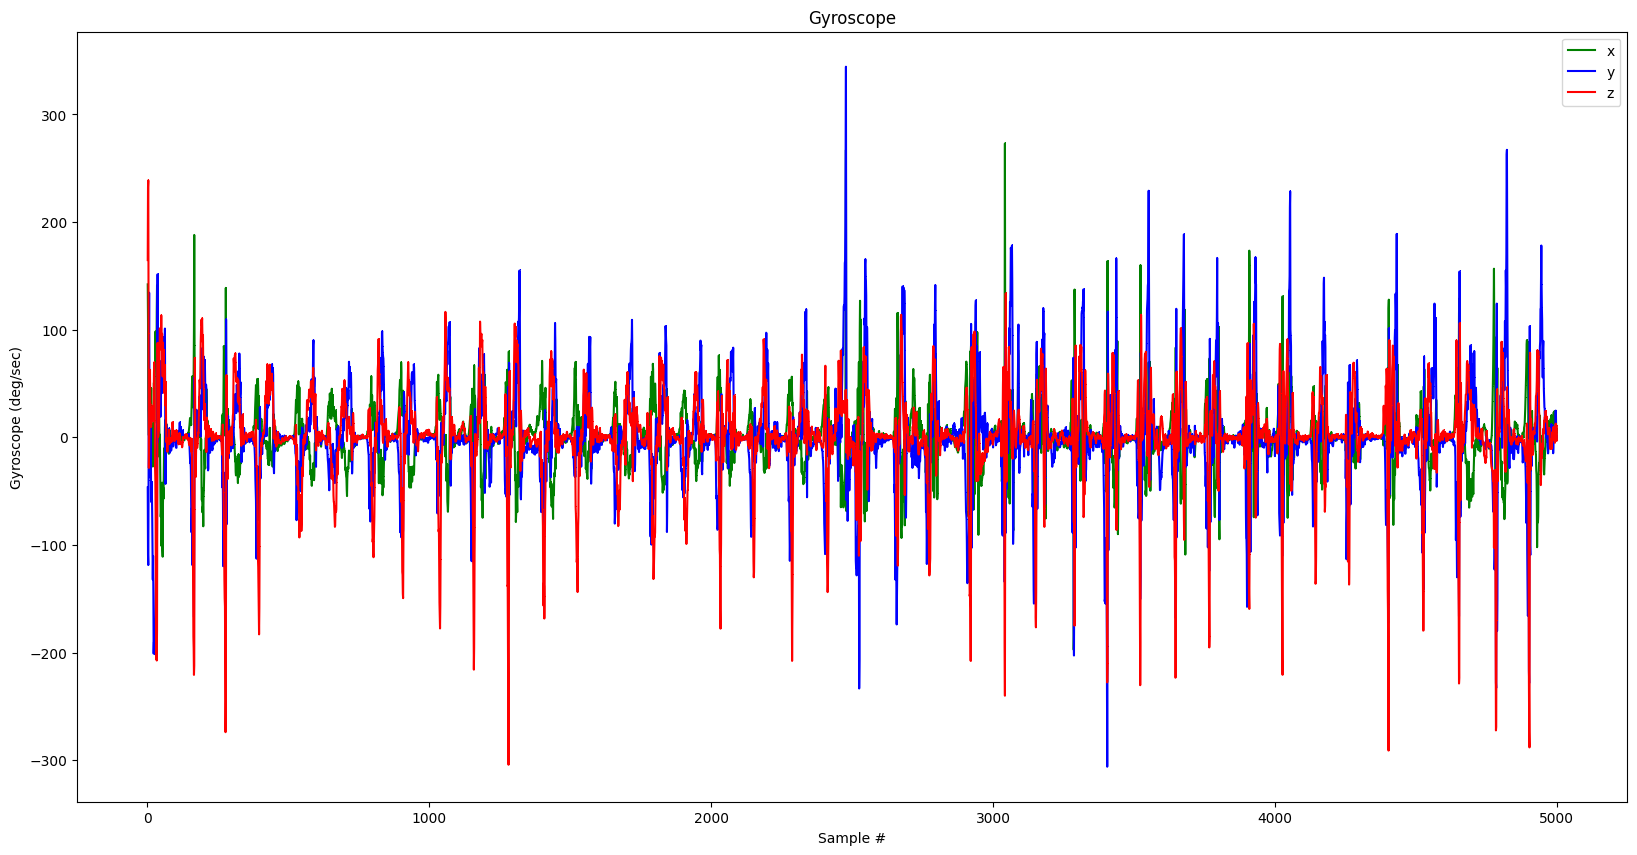

/tmp/ipykernel_364/3007413460.py:21: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "g." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['aX'], 'g.', label='x', linestyle='solid', marker=',')
/tmp/ipykernel_364/3007413460.py:22: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "b." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['aY'], 'b.', label='y', linestyle='solid', marker=',')
/tmp/ipykernel_364/3007413460.py:23: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "r." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['aZ'], 'r.', label='z', linestyle='solid', marker=',')


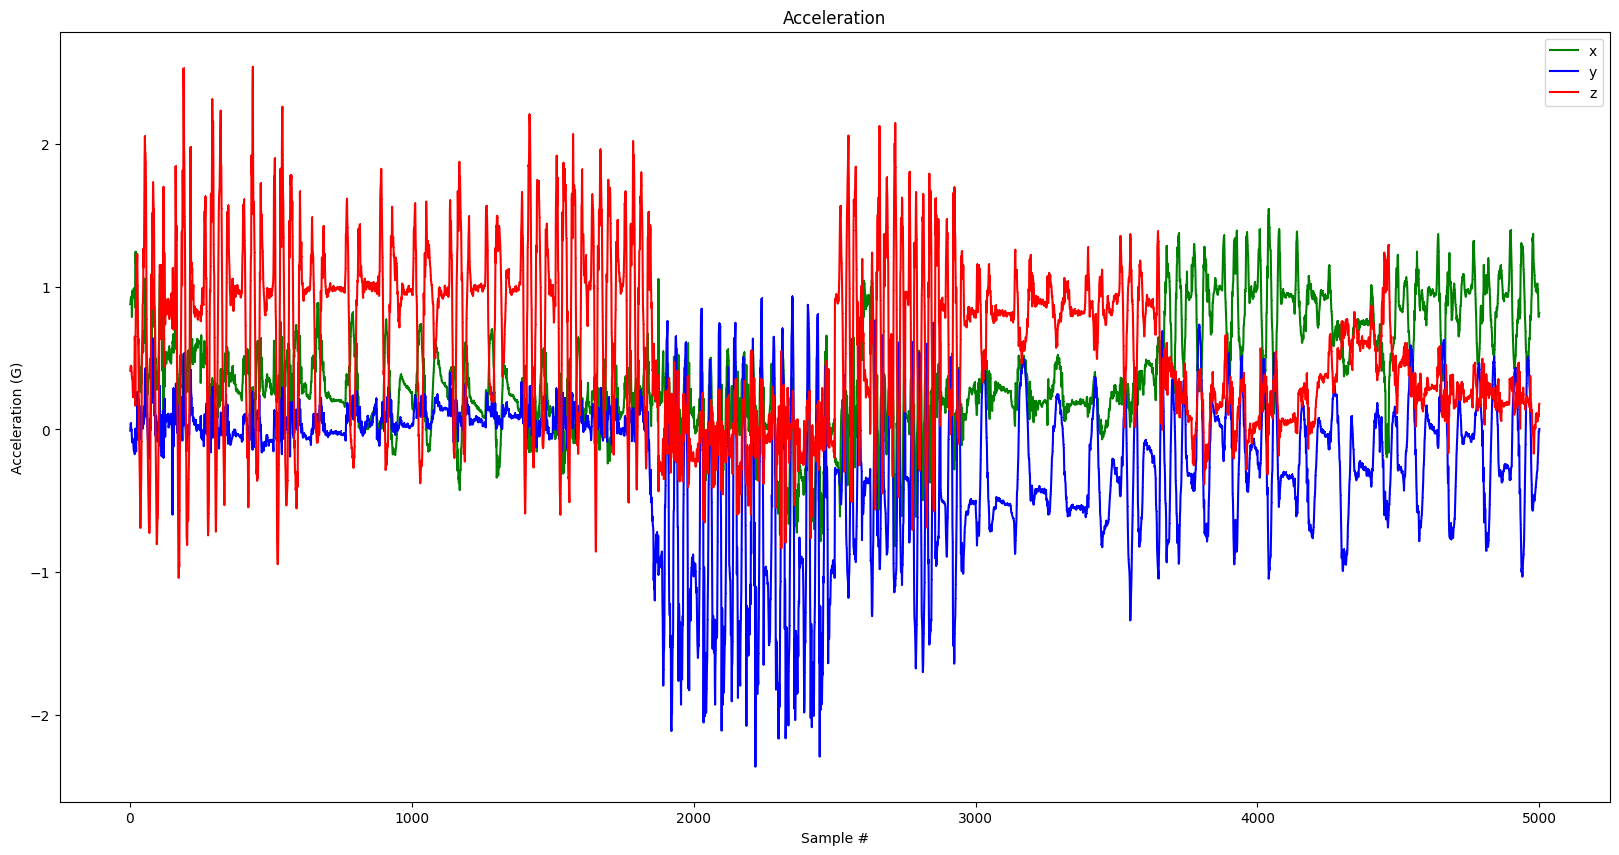

/tmp/ipykernel_364/3007413460.py:30: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "g." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['gX'], 'g.', label='x', linestyle='solid', marker=',')
/tmp/ipykernel_364/3007413460.py:31: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "b." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['gY'], 'b.', label='y', linestyle='solid', marker=',')
/tmp/ipykernel_364/3007413460.py:32: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "r." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['gZ'], 'r.', label='z', linestyle='solid', marker=',')


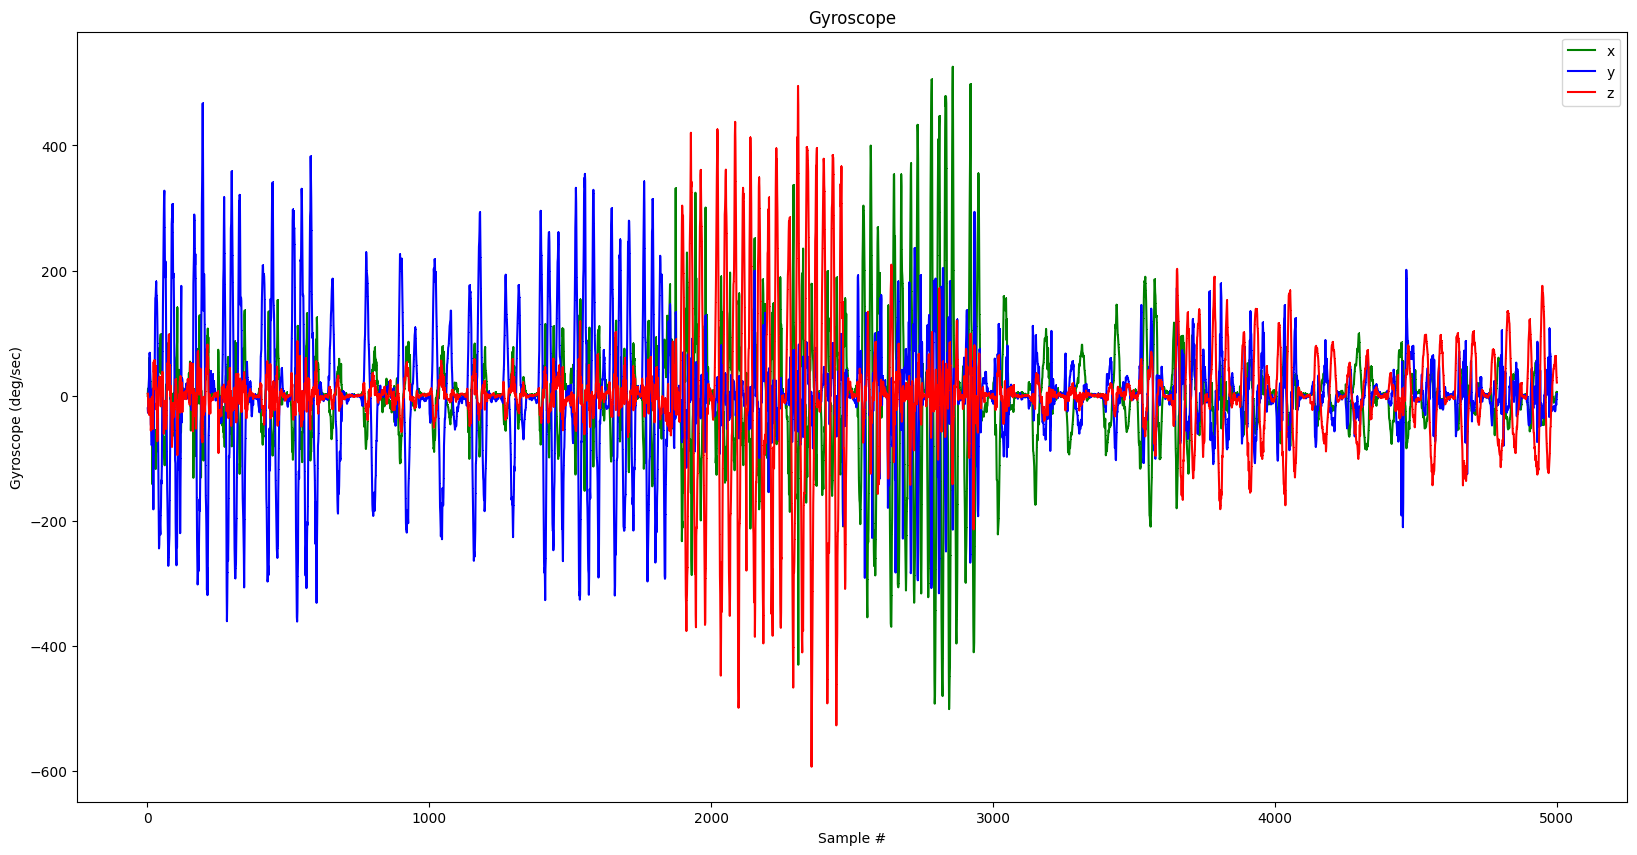

/tmp/ipykernel_364/3007413460.py:21: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "g." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['aX'], 'g.', label='x', linestyle='solid', marker=',')
/tmp/ipykernel_364/3007413460.py:22: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "b." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['aY'], 'b.', label='y', linestyle='solid', marker=',')
/tmp/ipykernel_364/3007413460.py:23: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "r." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['aZ'], 'r.', label='z', linestyle='solid', marker=',')


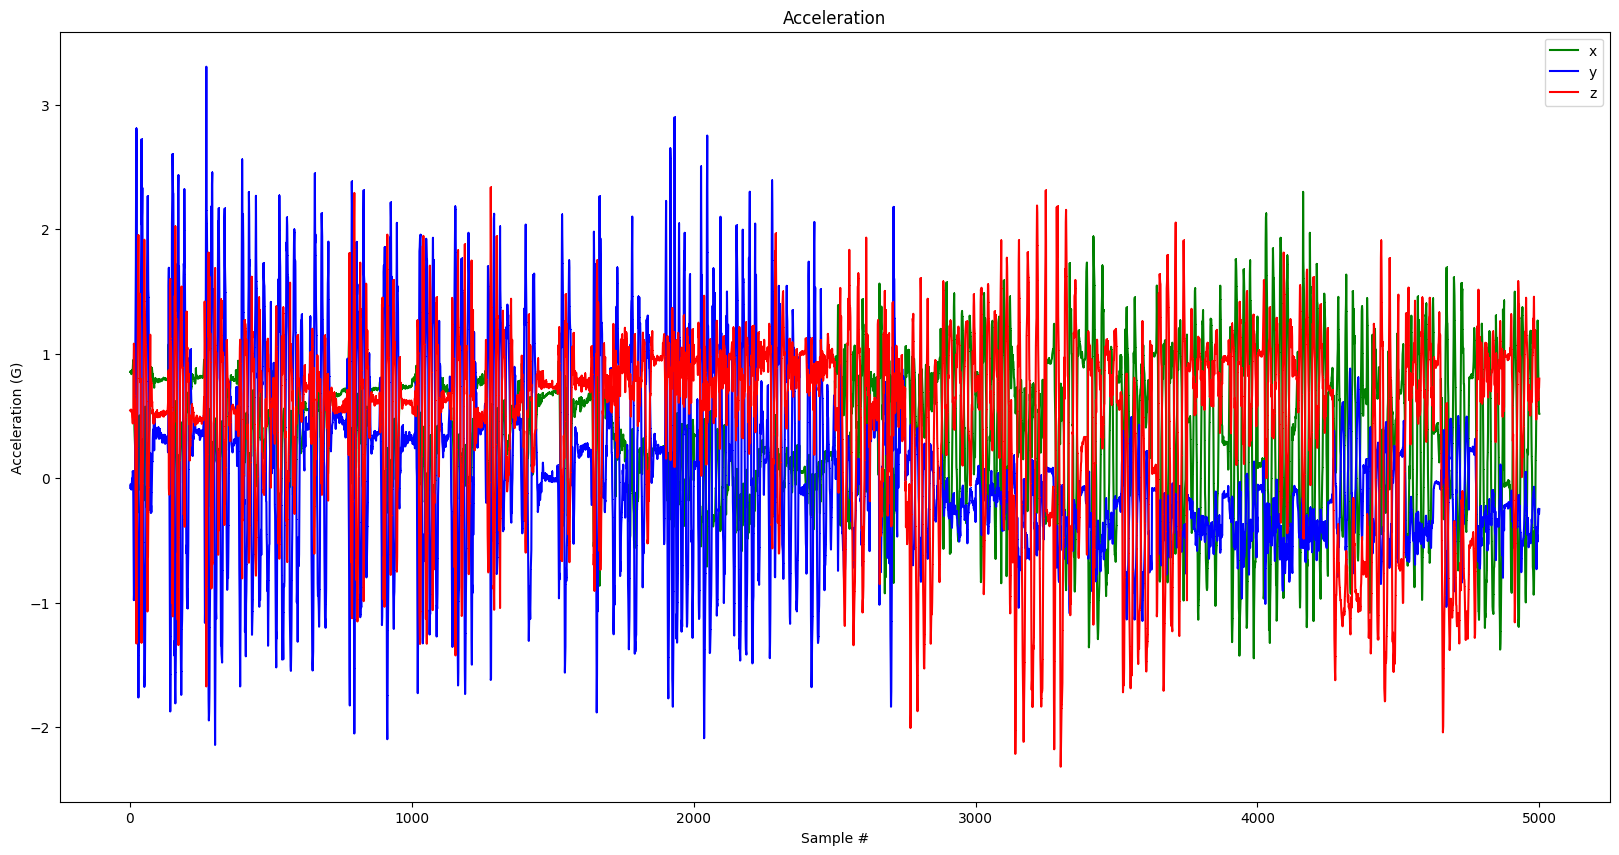

/tmp/ipykernel_364/3007413460.py:30: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "g." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['gX'], 'g.', label='x', linestyle='solid', marker=',')
/tmp/ipykernel_364/3007413460.py:31: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "b." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['gY'], 'b.', label='y', linestyle='solid', marker=',')
/tmp/ipykernel_364/3007413460.py:32: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "r." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['gZ'], 'r.', label='z', linestyle='solid', marker=',')


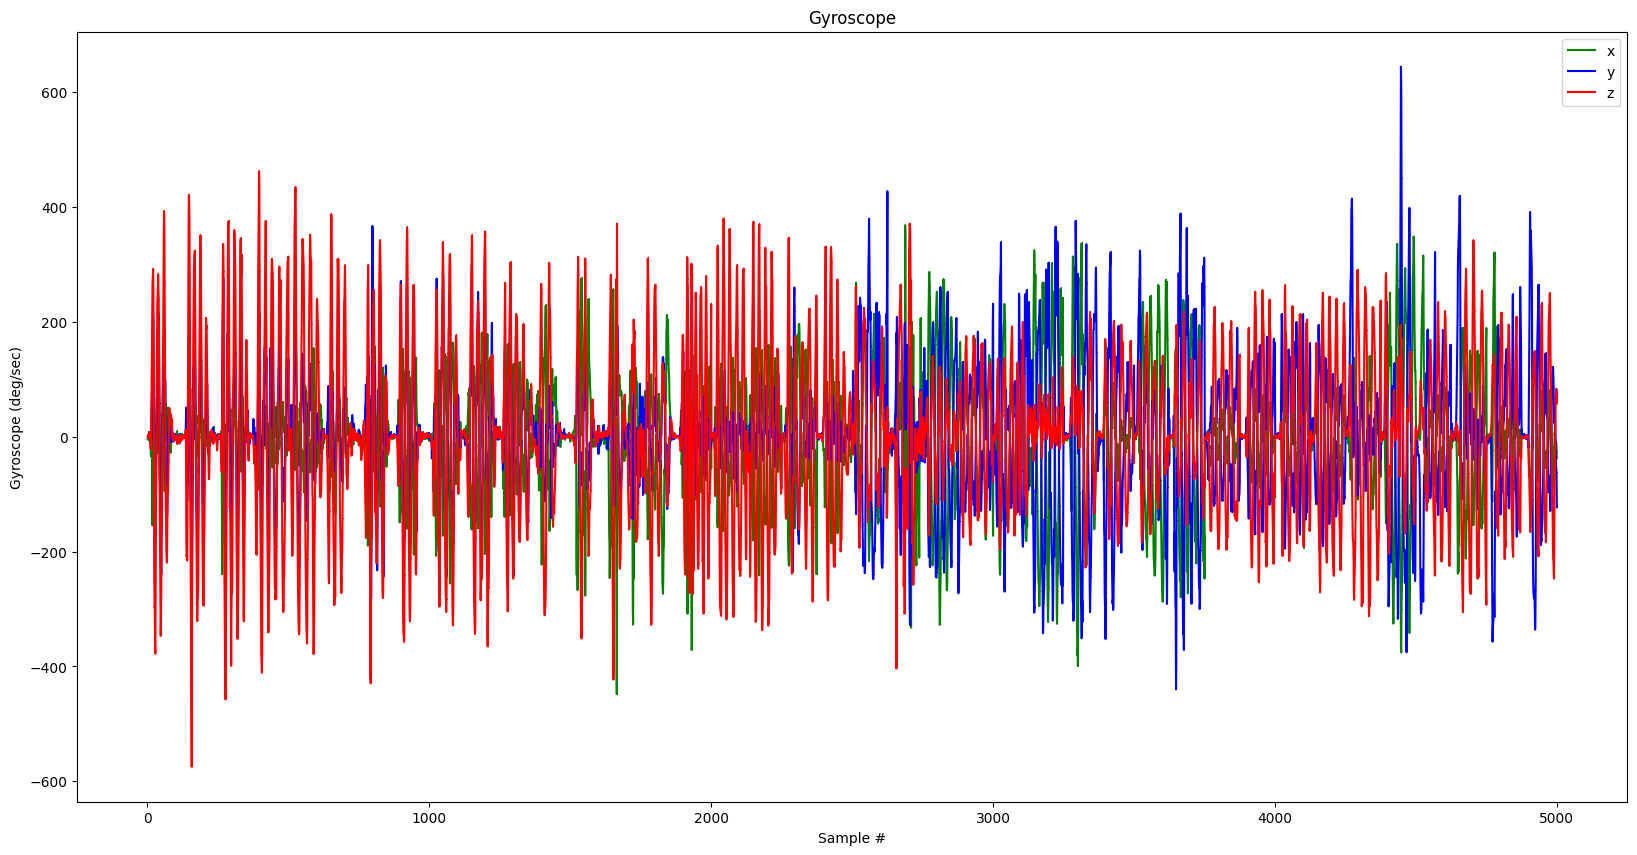

/tmp/ipykernel_364/3007413460.py:21: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "g." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['aX'], 'g.', label='x', linestyle='solid', marker=',')
/tmp/ipykernel_364/3007413460.py:22: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "b." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['aY'], 'b.', label='y', linestyle='solid', marker=',')
/tmp/ipykernel_364/3007413460.py:23: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "r." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['aZ'], 'r.', label='z', linestyle='solid', marker=',')


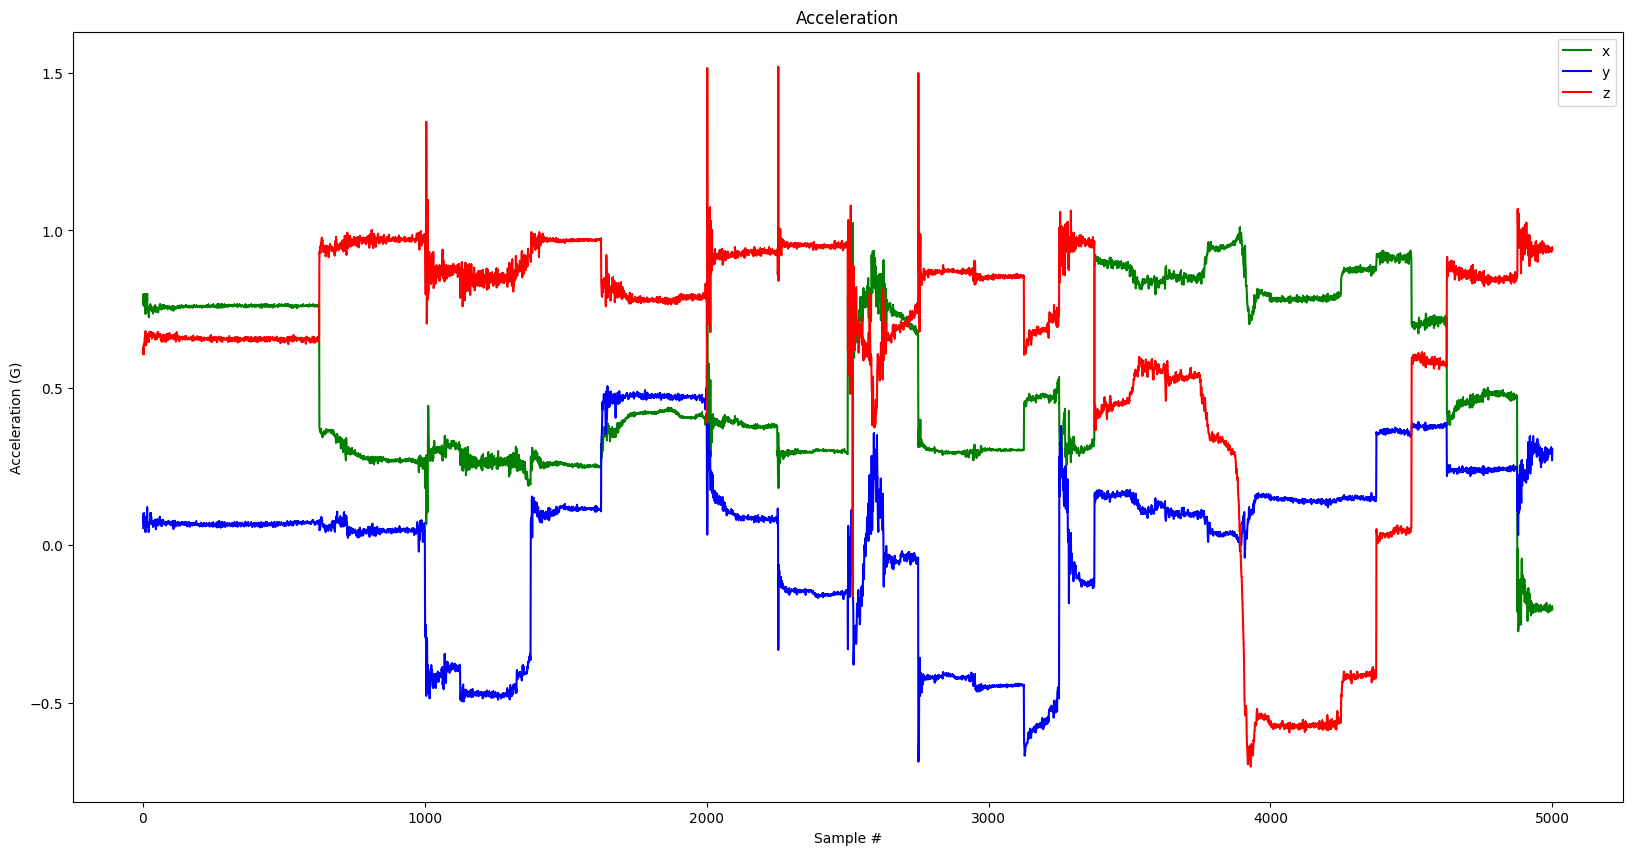

/tmp/ipykernel_364/3007413460.py:30: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "g." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['gX'], 'g.', label='x', linestyle='solid', marker=',')
/tmp/ipykernel_364/3007413460.py:31: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "b." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['gY'], 'b.', label='y', linestyle='solid', marker=',')
/tmp/ipykernel_364/3007413460.py:32: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "r." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['gZ'], 'r.', label='z', linestyle='solid', marker=',')


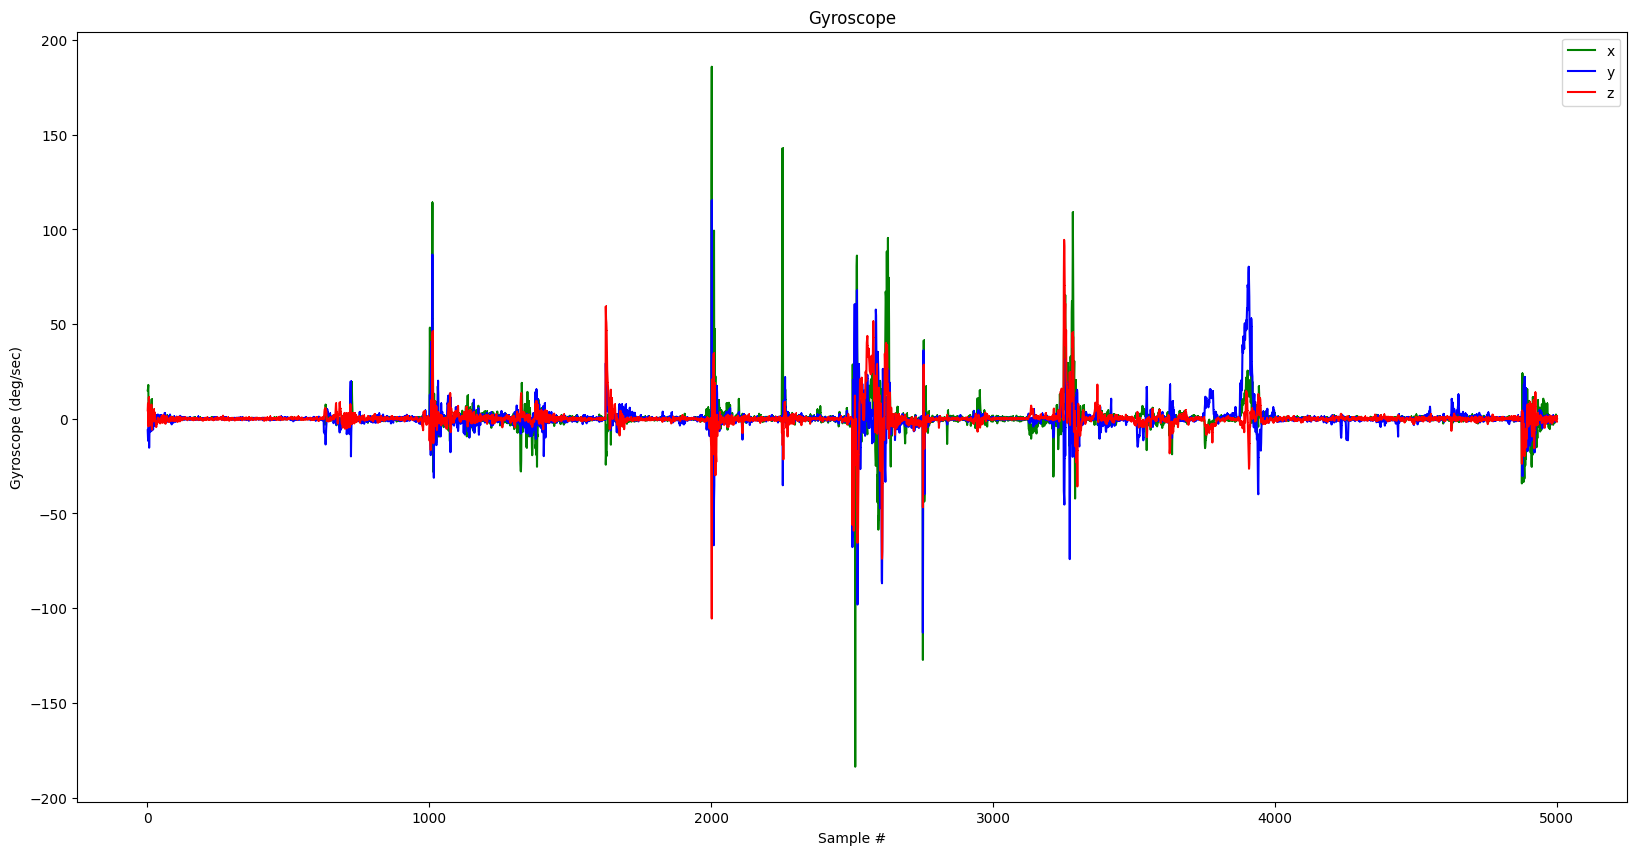

/tmp/ipykernel_364/3007413460.py:21: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "g." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['aX'], 'g.', label='x', linestyle='solid', marker=',')
/tmp/ipykernel_364/3007413460.py:22: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "b." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['aY'], 'b.', label='y', linestyle='solid', marker=',')
/tmp/ipykernel_364/3007413460.py:23: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "r." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['aZ'], 'r.', label='z', linestyle='solid', marker=',')


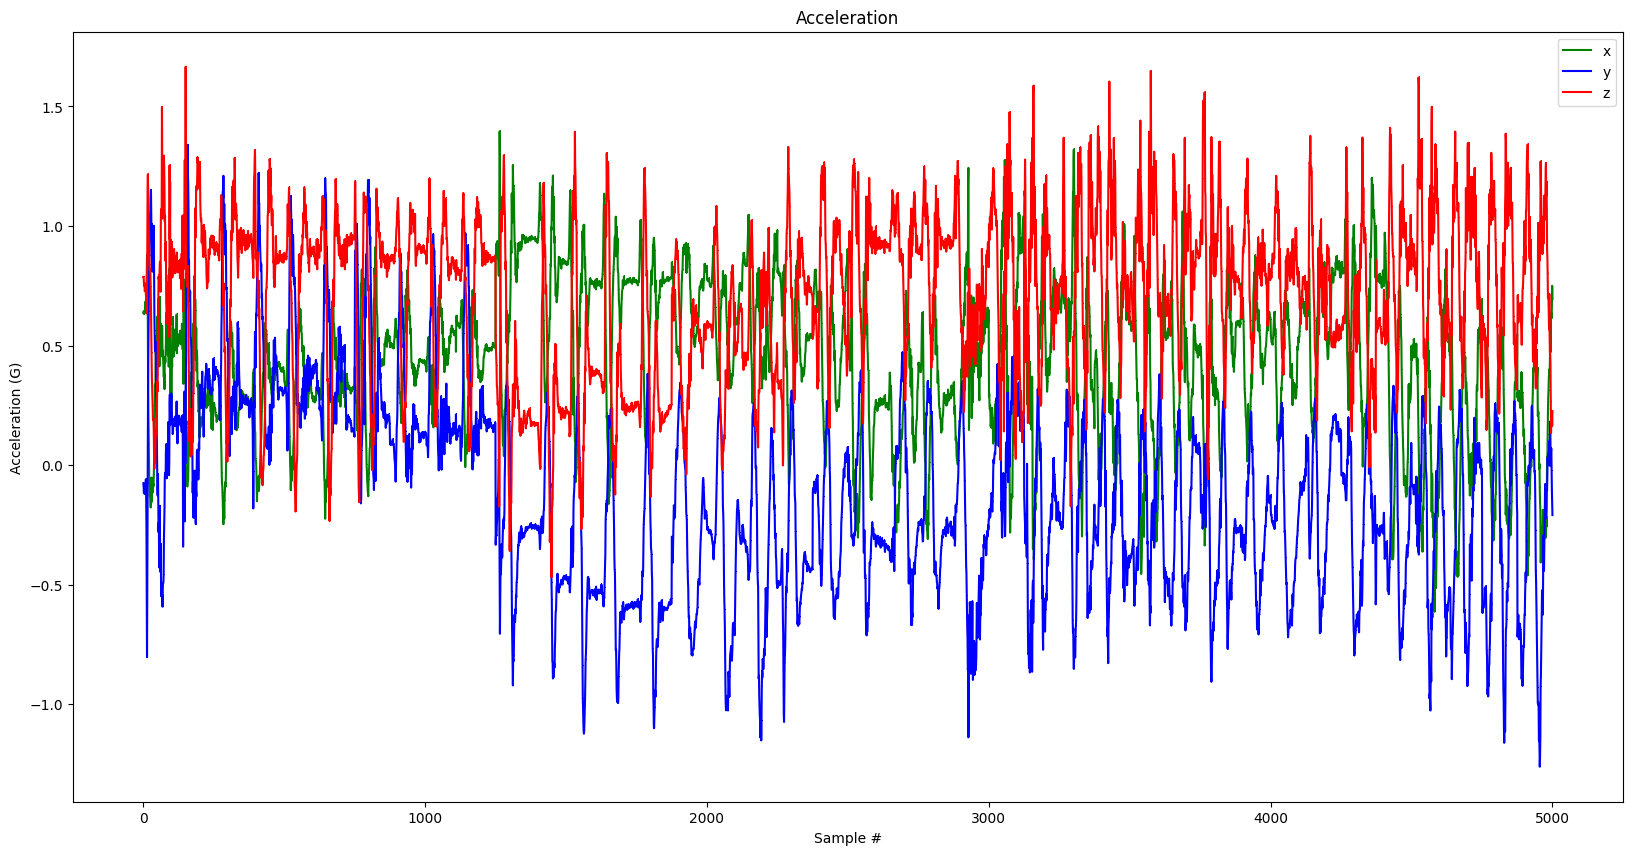

/tmp/ipykernel_364/3007413460.py:30: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "g." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['gX'], 'g.', label='x', linestyle='solid', marker=',')
/tmp/ipykernel_364/3007413460.py:31: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "b." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['gY'], 'b.', label='y', linestyle='solid', marker=',')
/tmp/ipykernel_364/3007413460.py:32: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "r." (-> marker='.'). The keyword argument will take precedence.
  plt.plot(index, df['gZ'], 'r.', label='z', linestyle='solid', marker=',')


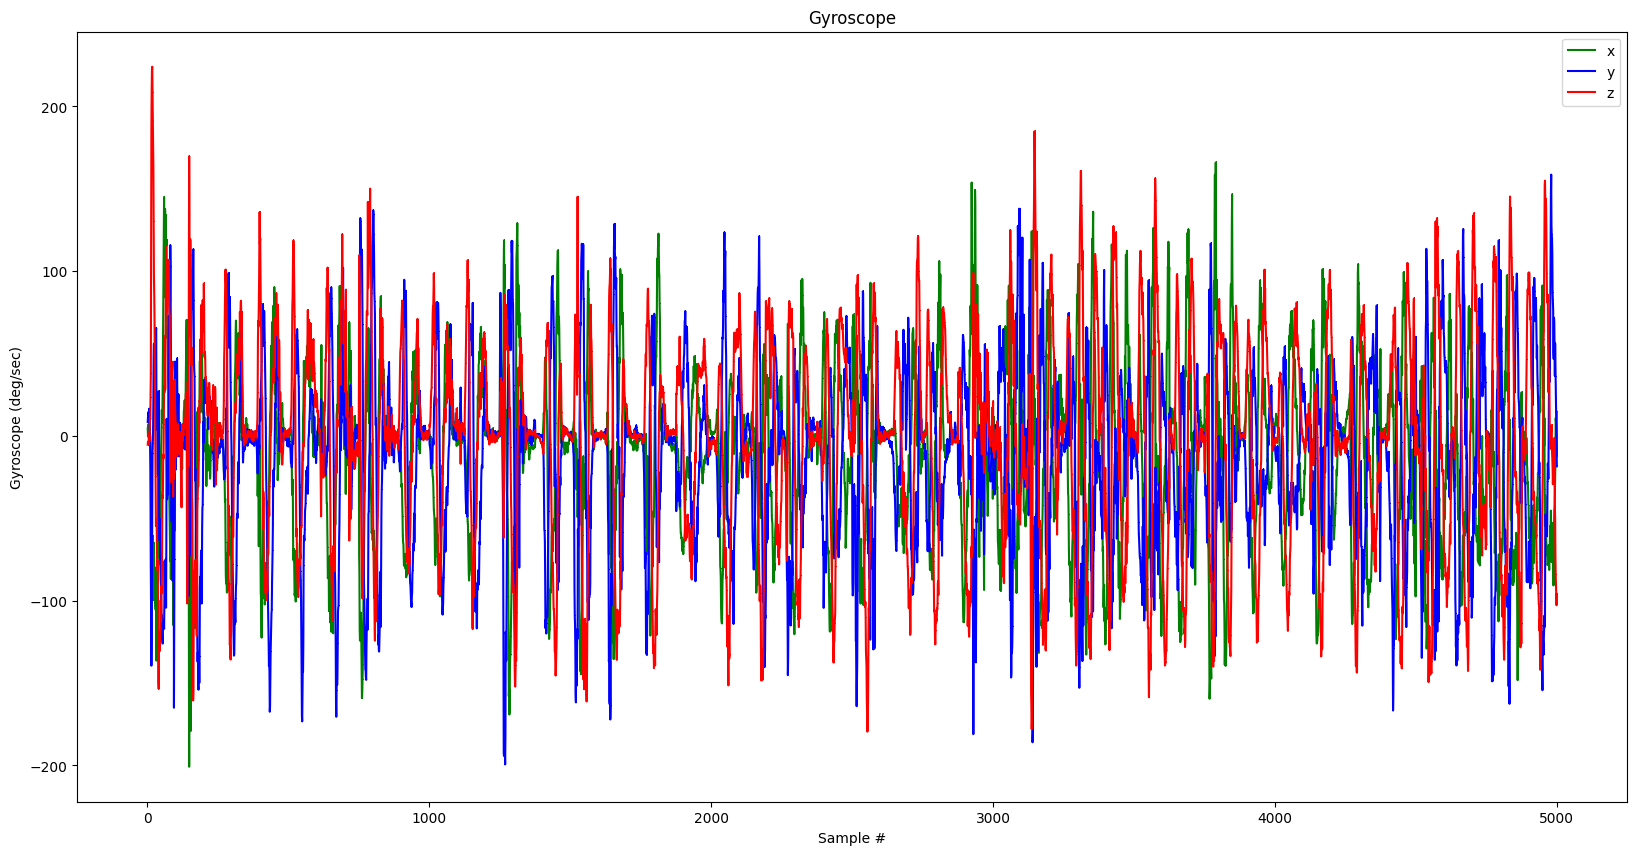

In [70]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

filename = "punch_2seconds.csv"
files = [
    "punch_2seconds.csv",
    "updown_2seconds.csv",
    "shake_2seconds.csv",
    "rest_2seconds.csv",
    "circle_2seconds.csv",
]

for f in files:
  df = pd.read_csv("/content/" + f)

  index = range(1, len(df['aX']) + 1)

  plt.rcParams["figure.figsize"] = (20,10)

  plt.plot(index, df['aX'], 'g.', label='x', linestyle='solid', marker=',')
  plt.plot(index, df['aY'], 'b.', label='y', linestyle='solid', marker=',')
  plt.plot(index, df['aZ'], 'r.', label='z', linestyle='solid', marker=',')
  plt.title("Acceleration")
  plt.xlabel("Sample #")
  plt.ylabel("Acceleration (G)")
  plt.legend()
  plt.show()

  plt.plot(index, df['gX'], 'g.', label='x', linestyle='solid', marker=',')
  plt.plot(index, df['gY'], 'b.', label='y', linestyle='solid', marker=',')
  plt.plot(index, df['gZ'], 'r.', label='z', linestyle='solid', marker=',')
  plt.title("Gyroscope")
  plt.xlabel("Sample #")
  plt.ylabel("Gyroscope (deg/sec)")
  plt.legend()
  plt.show()


# Train Neural Network





## Parse and prepare the data

The next cell parses the csv files and transforms them to a format that will be used to train the fully connected neural network.

Update the `GESTURES` list with the gesture data you've collected in `.csv` format.


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

print(f"TensorFlow version = {tf.__version__}\n")

# Set a fixed random seed value, for reproducibility, this will allow us to get
# the same random numbers each time the notebook is run
SEED = 1337
np.random.seed(SEED)
tf.random.set_seed(SEED)

# the list of gestures that data is available for
GESTURES = [
    "punch",
    "updown",
    "shake",
    "rest",
    "circle",
]

# files = [
#     "punch_2seconds.csv",
#     "updown_2seconds.csv",
#     "shake_2seconds.csv",
#     "rest_2seconds.csv",
#     "circle_2seconds.csv",
# ]

SAMPLES_PER_GESTURE = 125

NUM_GESTURES = len(GESTURES)

# create a one-hot encoded matrix that is used in the output
ONE_HOT_ENCODED_GESTURES = np.eye(NUM_GESTURES)

inputs = []
outputs = []

# read each csv file and push an input and output
for gesture_index in range(NUM_GESTURES):
  gesture = GESTURES[gesture_index]
  print(f"Processing index {gesture_index} for gesture '{gesture}'.")

  output = ONE_HOT_ENCODED_GESTURES[gesture_index]

  df = pd.read_csv("/content/" + gesture + "_2seconds.csv")

  # calculate the number of gesture recordings in the file
  num_recordings = int(df.shape[0] / SAMPLES_PER_GESTURE)

  print(f"\tThere are {num_recordings} recordings of the {gesture} gesture.")

  for i in range(num_recordings):
    # Compute RMS
    feature_extraced = []
    tensor = []

    aX = []
    aY = []
    aZ = []
    gX = []
    gY = []
    gZ = []

    for j in range(SAMPLES_PER_GESTURE):
      index = i * SAMPLES_PER_GESTURE + j
      # normalize the input data, between 0 to 1:
      # - acceleration is between: -4 to +4
      # - gyroscope is between: -2000 to +2000
      aX += [(df['aX'][index] + 4) / 8]
      aY += [(df['aY'][index] + 4) / 8]
      aZ += [(df['aZ'][index] + 4) / 8]
      gX += [(df['gX'][index] + 2000) / 4000]
      gY += [(df['gY'][index] + 2000) / 4000]
      gZ += [(df['gZ'][index] + 2000) / 4000]

    data_streams = {
      'aX': aX, 'aY': aY, 'aZ': aZ,
      'gX': gX, 'gY': gY, 'gZ': gZ
    }

    fs = 62.5
    N = SAMPLES_PER_GESTURE
    for label, data in data_streams.items():
      # 2. ADD PADDING: Add 3 zeros to reach N=128 (Matches Arduino)
      data += [0.0, 0.0, 0.0]
      N_padded = 128

      # 3. Time Domain Features (Calculated on padded 128 samples)
      avg = np.average(data)
      std = np.std(data)
      rms = np.sqrt(np.mean(np.square(data)))
      mini = np.min(data)
      maxi = np.max(data)

      # Add to tensor in the EXACT order Arduino expects for this axis
      tensor += [avg, std, rms, mini, maxi]

      # 4. Frequency Domain Features
      detrended = np.array(data) - avg
      fft_vals = np.fft.fft(detrended)
      psd = (np.abs(fft_vals)**2) / (N_padded * fs)
      psd_half = psd[:N_padded//2]

      # 5. Top 3 Peaks with "Neighbor Zeroing" (Matches Arduino logic)
      temp_psd = psd_half.copy()
      temp_psd[0] = 0 # Skip DC
      for _ in range(3):
          p_idx = np.argmax(temp_psd)
          p_amp = temp_psd[p_idx]
          p_freq = (p_idx * fs) / N_padded

          tensor += [p_amp, p_freq]

          # Zero out neighbor to find distinct peaks
          temp_psd[p_idx] = 0
          if p_idx > 0: temp_psd[p_idx-1] = 0
          if p_idx < len(temp_psd)-1: temp_psd[p_idx+1] = 0

      # 6. Spectral Bins
      bins = np.array_split(psd_half, 4)
      tensor += [np.sum(b) for b in bins]

    inputs.append(tensor)
    outputs.append(output)

# convert the list to numpy array
inputs = np.array(inputs)
outputs = np.array(outputs)

print("Data set parsing and preparation complete.")

TensorFlow version = 2.19.0

Processing index 0 for gesture 'punch'.
	There are 40 recordings of the punch gesture.
Processing index 1 for gesture 'updown'.
	There are 40 recordings of the updown gesture.
Processing index 2 for gesture 'shake'.
	There are 40 recordings of the shake gesture.
Processing index 3 for gesture 'rest'.
	There are 40 recordings of the rest gesture.
Processing index 4 for gesture 'circle'.
	There are 40 recordings of the circle gesture.
Data set parsing and preparation complete.


## Randomize and split the input and output pairs for training

Randomly split input and output pairs into sets of data: 60% for training, 20% for validation, and 20% for testing.

  - the training set is used to train the model
  - the validation set is used to measure how well the model is performing during training
  - the testing set is used to test the model after training

In [4]:
# Randomize the order of the inputs, so they can be evenly distributed for training, testing, and validation
# https://stackoverflow.com/a/37710486/2020087
num_inputs = len(inputs)
randomize = np.arange(num_inputs)
np.random.shuffle(randomize)

# Swap the consecutive indexes (0, 1, 2, etc) with the randomized indexes
inputs = inputs[randomize]
outputs = outputs[randomize]

# Split the recordings (group of samples) into three sets: training, testing and validation
TRAIN_SPLIT = int(0.6 * num_inputs)
TEST_SPLIT = int(0.2 * num_inputs + TRAIN_SPLIT)

inputs_train, inputs_test, inputs_validate = np.split(inputs, [TRAIN_SPLIT, TEST_SPLIT])
outputs_train, outputs_test, outputs_validate = np.split(outputs, [TRAIN_SPLIT, TEST_SPLIT])

print("Data set randomization and splitting complete.")

Data set randomization and splitting complete.


## Build & Train the Model

Build and train a [TensorFlow](https://www.tensorflow.org) model using the high-level [Keras](https://www.tensorflow.org/guide/keras) API.

In [71]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.6),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(NUM_GESTURES, activation='softmax')
])

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    inputs_train,
    outputs_train,
    epochs=400,
    batch_size=8,
    validation_data=(inputs_validate, outputs_validate),
    shuffle=True
)

Epoch 1/400
15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.1500 - loss: 2.8759 - val_accuracy: 0.2000 - val_loss: 1.6323
Epoch 2/400
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1417 - loss: 2.2362 - val_accuracy: 0.1750 - val_loss: 1.5952
Epoch 3/400
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1667 - loss: 2.1984 - val_accuracy: 0.1500 - val_loss: 1.5833
Epoch 4/400
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1917 - loss: 1.8604 - val_accuracy: 0.1750 - val_loss: 1.5882
Epoch 5/400
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1833 - loss: 1.8071 - val_accuracy: 0.1250 - val_loss: 1.5961
Epoch 6/400
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2500 - loss: 1.7225 - val_accuracy: 0.1750 - val_loss: 1.5985
Epoch 7/400
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1750 - loss: 1.7775 - val_accuracy: 0.1750 - val_loss: 1.6018
Epoch 8/400
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1917 - loss: 1.8134 - val_accuracy: 0.2000 - 

## Verify

Graph the models performance vs validation.


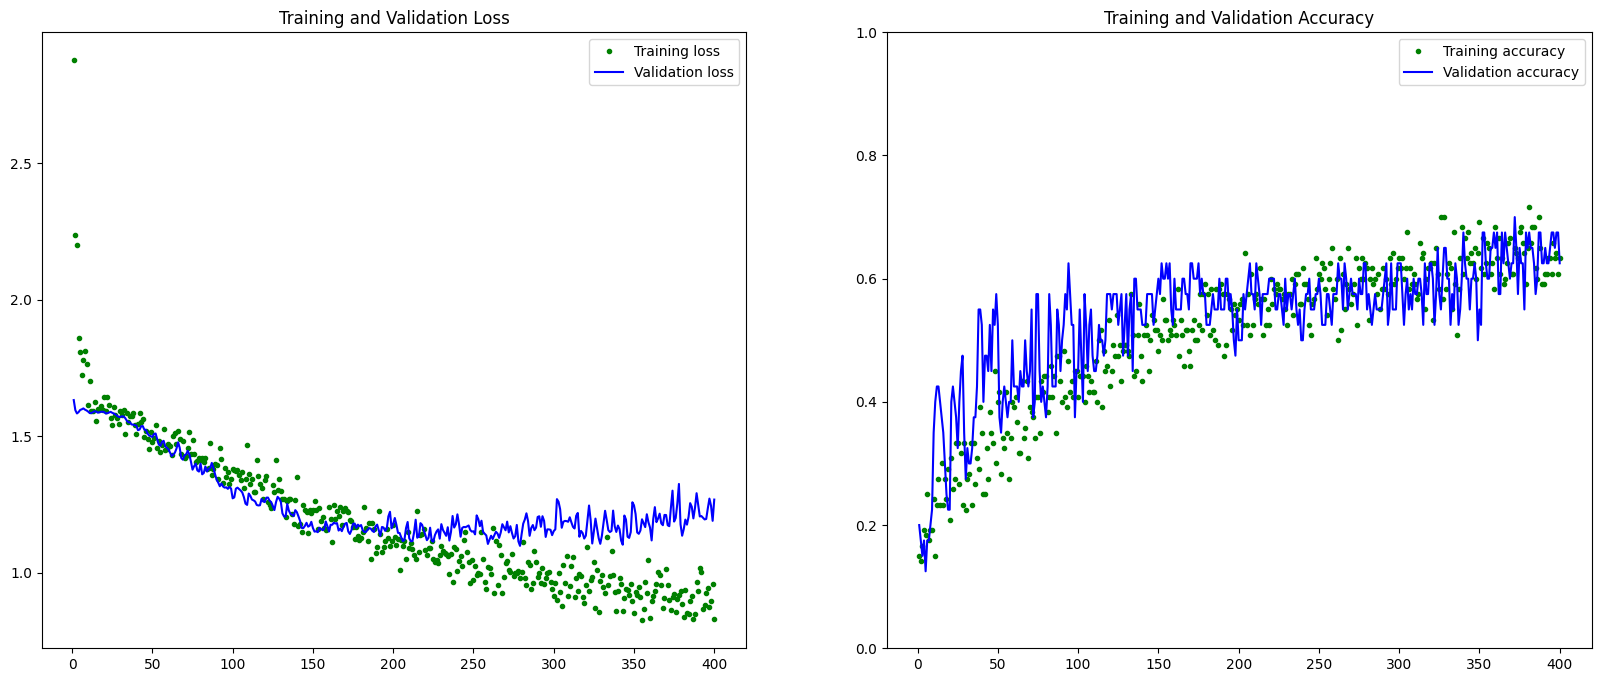

In [72]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

# Plot Loss
epochs = range(1, len(history.history['loss']) + 1)
ax1.plot(epochs, history.history['loss'], 'g.', label='Training loss')
ax1.plot(epochs, history.history['val_loss'], 'b', label='Validation loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()

# Plot Accuracy
ax2.plot(epochs, history.history['accuracy'], 'g.', label='Training accuracy')
ax2.plot(epochs, history.history['val_accuracy'], 'b', label='Validation accuracy')
ax2.set_title('Training and Validation Accuracy')
ax2.set_ylim([0, 1])
ax2.legend()

plt.show()

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


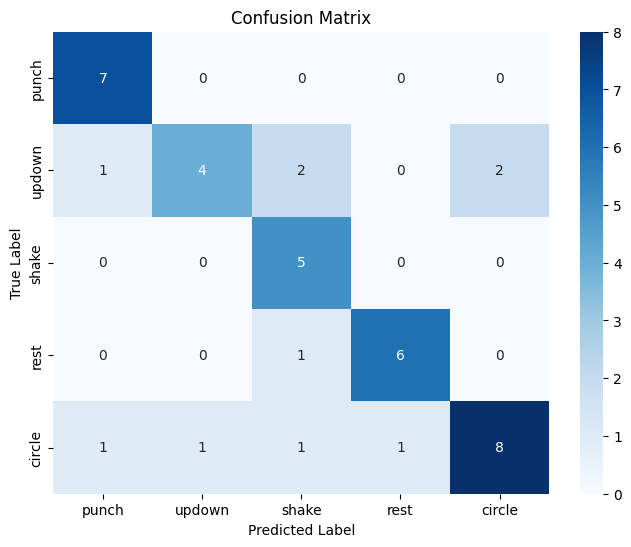

In [73]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

predictions = model.predict(inputs_test)
# Get the predicted labels (index of the highest probability)
predicted_labels = predictions.argmax(axis=1)
# Get the actual labels
actual_labels = outputs_test.argmax(axis=1)

# Compute the confusion matrix
cm = confusion_matrix(actual_labels, predicted_labels)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=GESTURES, yticklabels=GESTURES)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [74]:
loss, accuracy = model.evaluate(inputs_test, outputs_test)
print(f"Loss on the test data: {loss:.4f}")
print(f"Accuracy on the test data: {accuracy:.4f}")

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7500 - loss: 1.4217 
Loss on the test data: 1.4217
Accuracy on the test data: 0.7500


# Convert the Trained Model to Tensor Flow Lite

The next cell converts the model to TFlite format. The size in bytes of the model is also printed out.

In [75]:
# Convert the model to the TensorFlow Lite format without quantization
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the model to disk
open("gesture_model.tflite", "wb").write(tflite_model)

import os
basic_model_size = os.path.getsize("gesture_model.tflite")
print("Model is %d bytes" % basic_model_size)



Saved artifact at '/tmp/tmp45bywbfk'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(8, 90), dtype=tf.float32, name='keras_tensor_120')
Output Type:
  TensorSpec(shape=(8, 5), dtype=tf.float32, name=None)
Captures:
  137402384786704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137402546251024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137402546249680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137402546250832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137402546250640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137402546251600: TensorSpec(shape=(), dtype=tf.resource, name=None)
Model is 16148 bytes


## Encode the Model in an Arduino Header File

The next cell creates a constant byte array that contains the TFlite model. Import it as a tab with the sketch below.

In [76]:
!echo "const unsigned char model[] = {" > /content/model.h
!cat gesture_model.tflite | xxd -i      >> /content/model.h
!echo "};"                              >> /content/model.h

import os
model_h_size = os.path.getsize("model.h")
print(f"Header file, model.h, is {model_h_size:,} bytes.")
print("\nOpen the side panel (refresh if needed). Double click model.h to download the file.")

Header file, model.h, is 99,614 bytes.

Open the side panel (refresh if needed). Double click model.h to download the file.


# Classifying IMU Data

Now it's time to switch back to the tutorial instructions and run our new model on the Arduino Nano 33 BLE Sense to classify the accelerometer and gyroscope data.
